In [ ]:
%matplotlib inline
import unicodedata

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
from pathlib import Path

# Paths
ROOT = Path("..").resolve()
DATA_PROC = ROOT / "data" / "processed"
DATA_PRIM = ROOT / "data" / "primary"

# Style
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "figure.dpi": 150,
    }
)

# Constants
LOCALIDAD_MAP = {
    1: "Usaquen",
    2: "Chapinero",
    3: "Santa Fe",
    4: "San Cristobal",
    5: "Usme",
    6: "Tunjuelito",
    7: "Bosa",
    8: "Kennedy",
    9: "Fontibon",
    10: "Engativa",
    11: "Suba",
    12: "Barrios Unidos",
    13: "Teusaquillo",
    14: "Los Martires",
    15: "Antonio Narino",
    16: "Puente Aranda",
    17: "Candelaria",
    18: "Rafael Uribe Uribe",
    19: "Ciudad Bolivar",
    20: "Sumapaz",
}

COLORS6 = ["#d73027", "#fc8d59", "#fee090", "#91bfdb", "#4575b4", "#313695"]


def strip_accents(s: str) -> str:
    return "".join(
        c
        for c in unicodedata.normalize("NFD", str(s))
        if unicodedata.category(c) != "Mn"
    )


# Load familias_expandidas
print("Loading familias_expandidas ...")
fam = pd.read_parquet(DATA_PROC / "familias_expandidas.parquet")
mask_ingreso = (fam["n_hijos_ingreso"] > 0).values
fam_ing = fam[mask_ingreso].copy().reset_index(drop=True)
fam_ing["localidad_nombre"] = fam_ing["COD_LOCALIDAD"].map(LOCALIDAD_MAP)
print(f"  primer ingreso: {len(fam_ing):,} / {len(fam):,} total")

# Load colegios (colegios_capacidad.parquet — incluye capacidad y a_j)
print("Loading colegios ...")
colegios = pd.read_parquet(DATA_PRIM / "colegios_capacidad.parquet")
colegios["localidad_ascii"] = colegios["nombre_localidad"].apply(strip_accents)
colegios["id_establecimiento"] = colegios["id_establecimiento"].astype(str)

# Load preferencias (positional join — same row order as familias_expandidas)
print("Loading preferencias ...")
pref_raw = pd.read_parquet(DATA_PRIM / "preferencias_familias.parquet")
pref_ing = pref_raw.iloc[mask_ingreso].reset_index(drop=True)
pref_cols = [c for c in pref_raw.columns if c.startswith("pref_")]
fam_ing[pref_cols] = pref_ing[pref_cols].values

# Load distancias
print("Loading distancias (may take ~60 s) ...")
dist_all = pd.read_parquet(DATA_PROC / "distancias_expandidas.parquet")
dist_min_all = dist_all.min(axis=1).values
del dist_all
fam_ing["dist_min"] = dist_min_all[mask_ingreso]

print(f"  pref columns found: {len(pref_cols)}")
print("  All data loaded.")

# Estrato integers
fam_ing["estrato_int"] = fam_ing["estrato_real"].dropna().astype(int)
strato_vals = sorted(fam_ing["estrato_int"].dropna().unique())

## Fig 1: Oferta vs Demanda por Localidad

Compara el numero de familias de primer ingreso contra los cupos disponibles por localidad,
ordenadas por deficit (familias - cupos). Permite identificar zonas con mayor presion sobre el sistema.

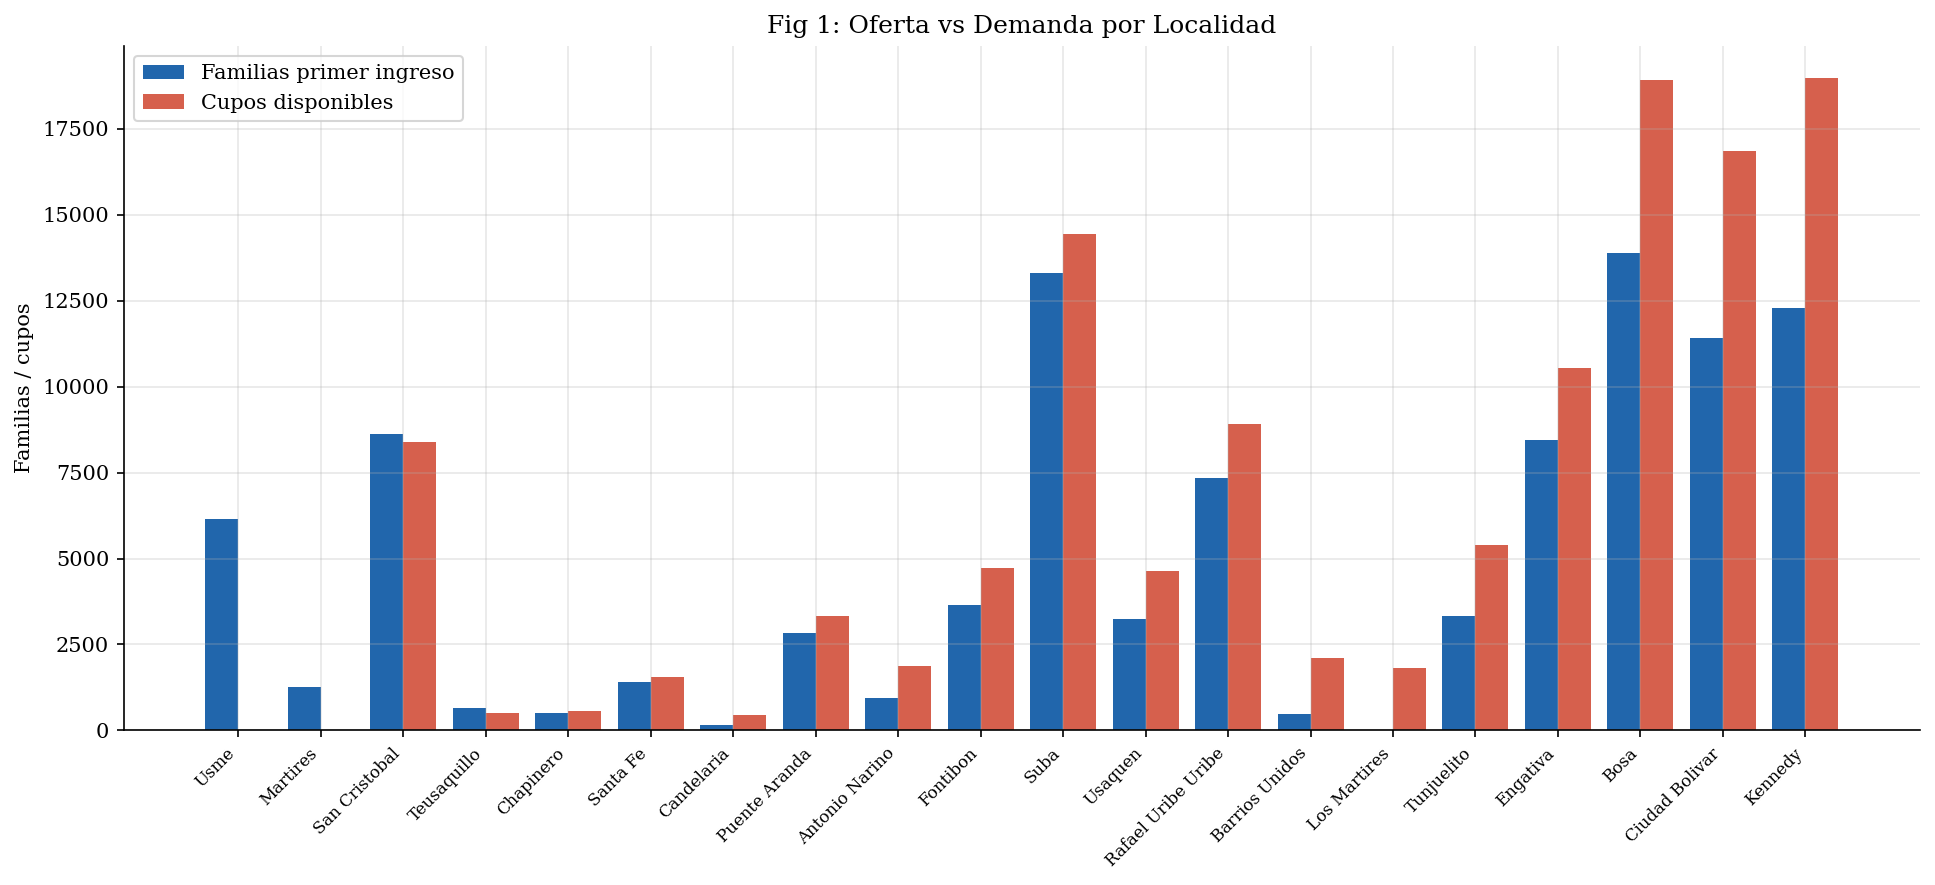

In [2]:
cupos = colegios.groupby("localidad_ascii")["capacidad"].sum().rename("cupos")
demanda = fam_ing.groupby("localidad_nombre").size().rename("familias")
# Normalizar índices: strip tildes para garantizar match
import unicodedata
def _asc(s):
    return "".join(c for c in unicodedata.normalize("NFD", str(s))
                   if unicodedata.category(c) != "Mn").strip()
cupos.index   = cupos.index.map(_asc)
demanda.index = demanda.index.map(_asc)
df1 = pd.concat([cupos, demanda], axis=1).fillna(0)
df1["deficit"] = df1["familias"] - df1["cupos"]
df1 = df1.sort_values("deficit", ascending=False)

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(df1))
w = 0.4
ax.bar(x - w / 2, df1["familias"], width=w, color="#2166ac", label="Familias primer ingreso")
ax.bar(x + w / 2, df1["cupos"],    width=w, color="#d6604d", label="Cupos disponibles")
ax.set_xticks(x)
ax.set_xticklabels(df1.index, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Familias / cupos")
ax.set_title("Fig 1: Oferta vs Demanda por Localidad")
ax.legend()
plt.tight_layout()


plt.savefig(r"C:\paper-AI\reports\figures\eda\sim_01_oferta_demanda_localidad.png", bbox_inches="tight", dpi=180)
plt.show()

## Fig 2: Calidad (q_j) por Localidad

Boxplot de calidad de los colegios (q_j) por localidad, ordenada de menor a mayor estrato promedio
ponderado. El color indica el nivel socioeconomico del entorno del colegio.

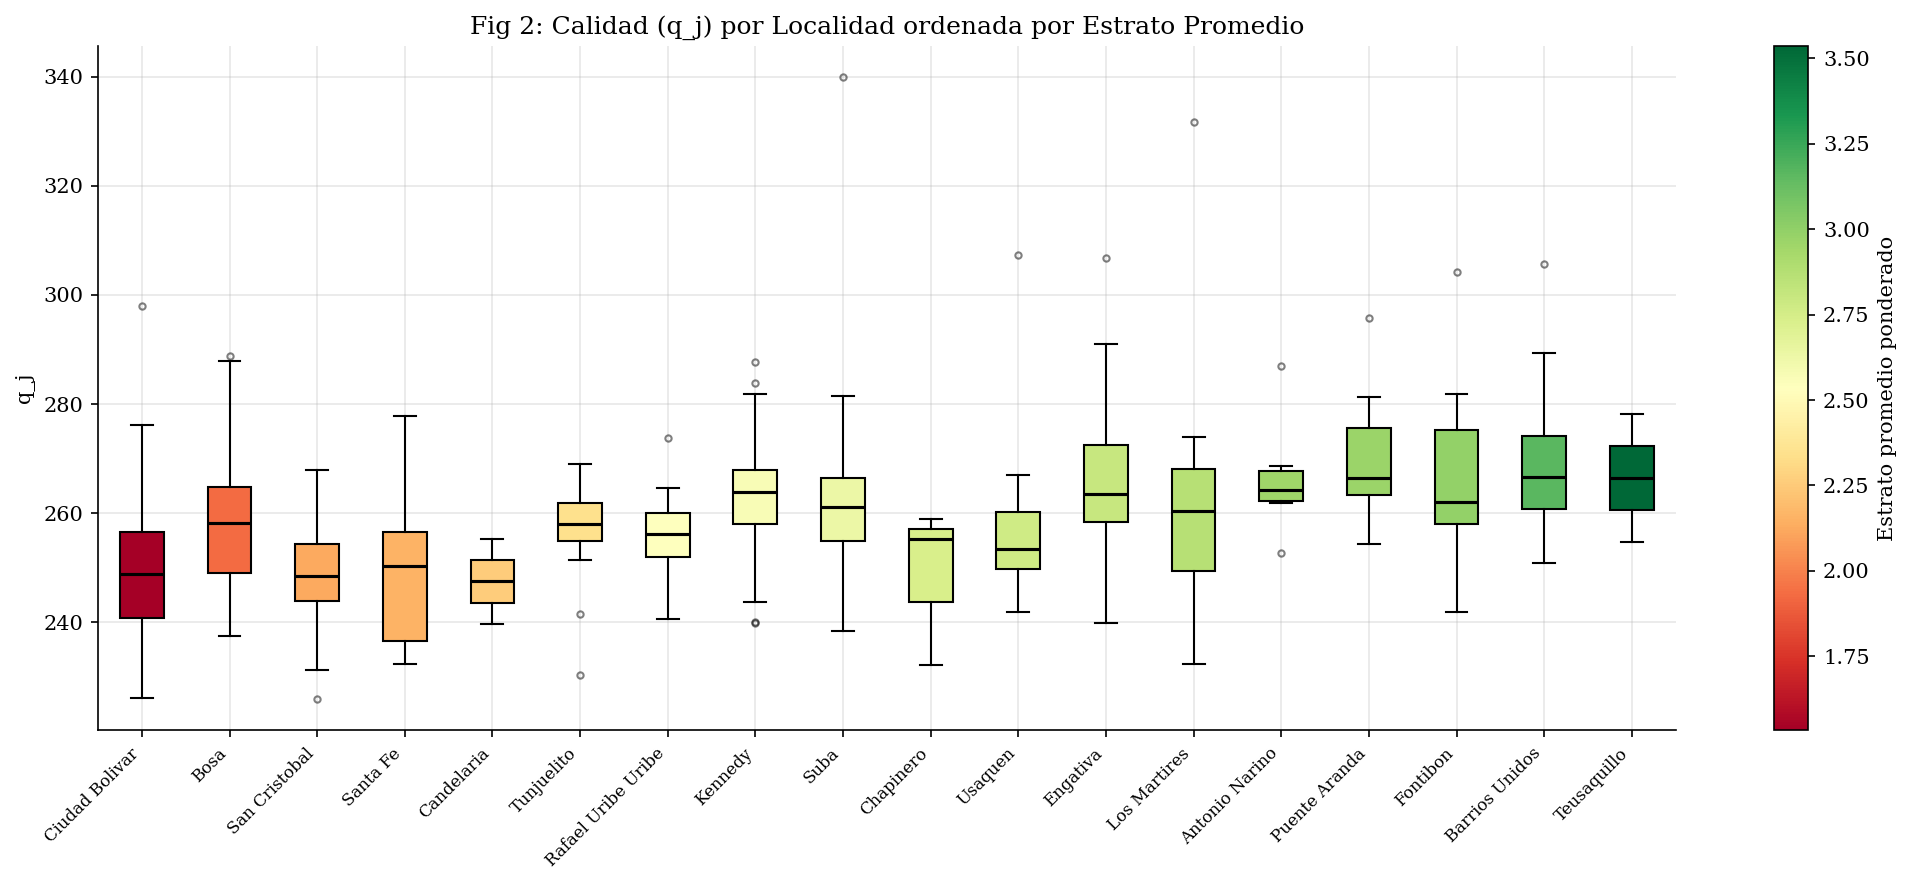

In [3]:
estrato_pct_cols = [f"pct_estrato_{i}" for i in range(1, 7)]
weights = np.arange(1, 7, dtype=float)
colegios["estrato_prom"] = colegios[estrato_pct_cols].fillna(0).values @ weights
ep_by_loc = colegios.groupby("localidad_ascii")["estrato_prom"].mean().sort_values()
ordered2 = ep_by_loc.index.tolist()

box_data2 = [
    colegios.loc[colegios["localidad_ascii"] == loc, "q_j"].dropna().values
    for loc in ordered2
]
cmap2 = plt.cm.RdYlGn
norm2 = mcolors.Normalize(vmin=ep_by_loc.min(), vmax=ep_by_loc.max())

fig, ax = plt.subplots(figsize=(14, 6))
bp2 = ax.boxplot(
    box_data2,
    patch_artist=True,
    notch=False,
    medianprops={"color": "black", "linewidth": 1.5},
    flierprops={"markersize": 3, "alpha": 0.5},
)
for patch, loc in zip(bp2["boxes"], ordered2):
    patch.set_facecolor(cmap2(norm2(ep_by_loc[loc])))
ax.set_xticklabels(ordered2, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("q_j")
ax.set_title("Fig 2: Calidad (q_j) por Localidad ordenada por Estrato Promedio")
sm2 = plt.cm.ScalarMappable(cmap=cmap2, norm=norm2)
sm2.set_array([])
fig.colorbar(sm2, ax=ax, label="Estrato promedio ponderado")
plt.tight_layout()


plt.savefig(r"C:\paper-AI\reports\figures\eda\sim_02_calidad_localidad.png", bbox_inches="tight", dpi=180)
plt.show()

## Fig 3: Segregacion Espacial (Localidad x Estrato)

Heatmap de la composicion de estrato de las familias de primer ingreso por localidad.
Filas normalizadas para mostrar la distribucion relativa; ordenadas por estrato medio.

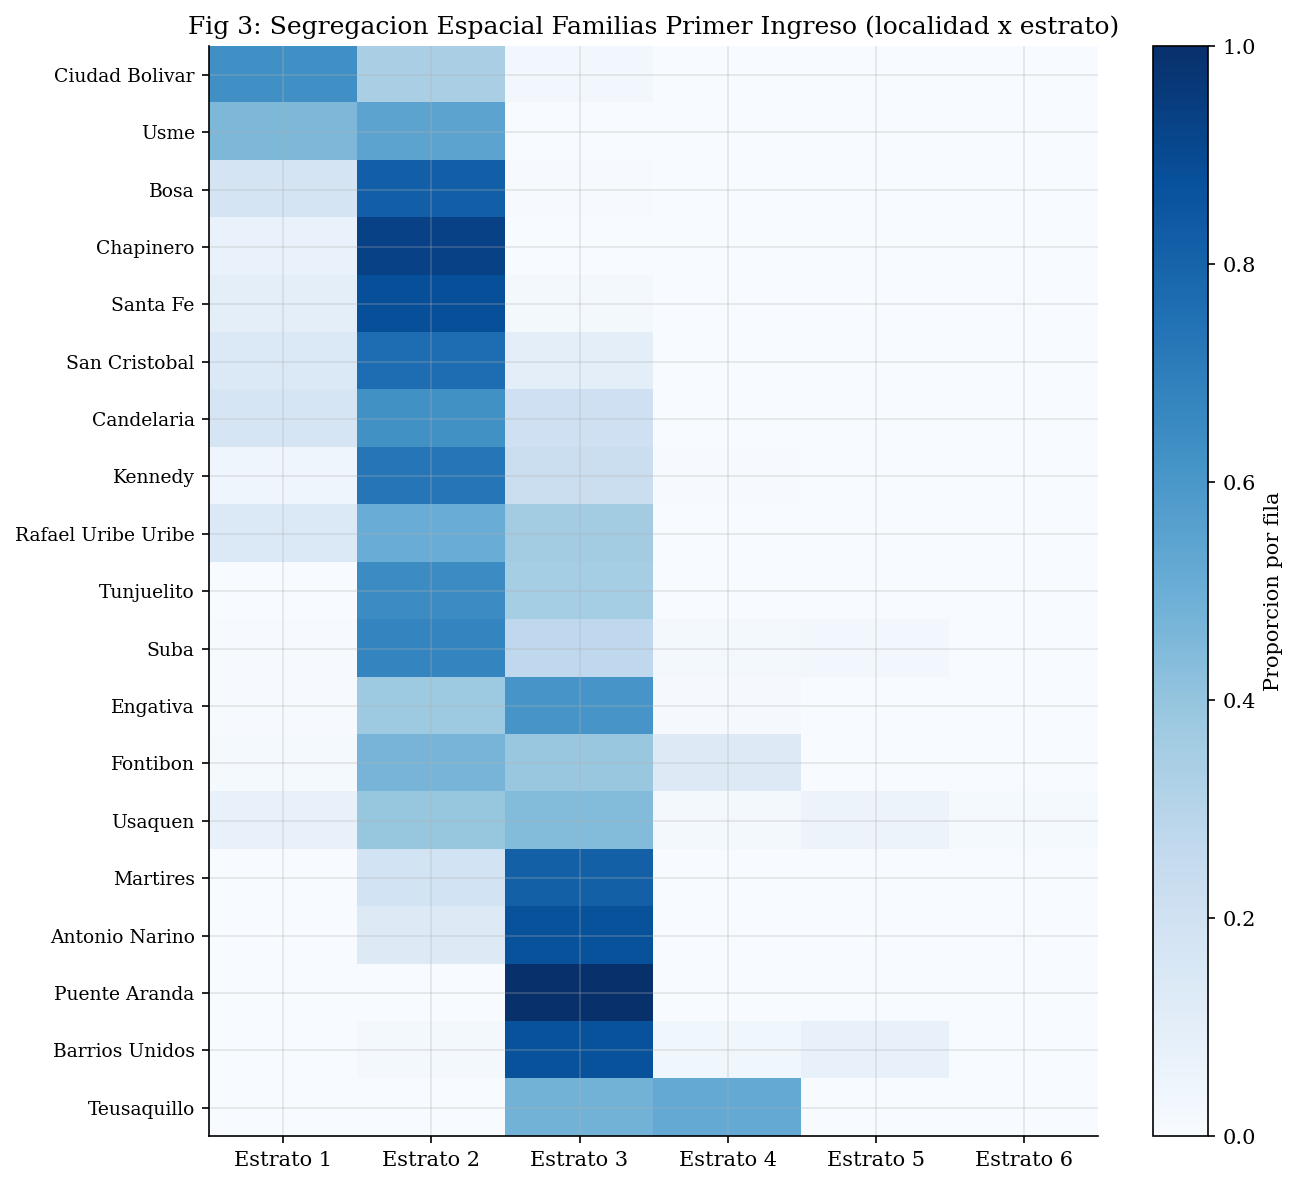

In [4]:
cross = pd.crosstab(fam_ing["localidad_nombre"], fam_ing["estrato_int"])
for c in range(1, 7):
    if c not in cross.columns:
        cross[c] = 0
cross = cross[[1, 2, 3, 4, 5, 6]]
cross_norm = cross.div(cross.sum(axis=1), axis=0)
row_score = cross_norm.values @ np.arange(1, 7, dtype=float)
cross_norm = cross_norm.iloc[np.argsort(row_score)]

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cross_norm.values, aspect="auto", cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(6))
ax.set_xticklabels([f"Estrato {i}" for i in range(1, 7)], fontsize=10)
ax.set_yticks(range(len(cross_norm)))
ax.set_yticklabels(cross_norm.index, fontsize=9)
ax.set_title("Fig 3: Segregacion Espacial Familias Primer Ingreso (localidad x estrato)")
fig.colorbar(im, ax=ax, label="Proporcion por fila")
plt.tight_layout()


plt.savefig(r"C:\paper-AI\reports\figures\eda\sim_03_segregacion_estrato.png", bbox_inches="tight", dpi=180)
plt.show()

## Fig 4: Distancias al Colegio Mas Cercano por Estrato

Distribucion de la distancia minima (km) al colegio mas cercano para las familias de primer ingreso,
desagregada por estrato. Muestra si hay diferencias sistematicas de acceso geografico.

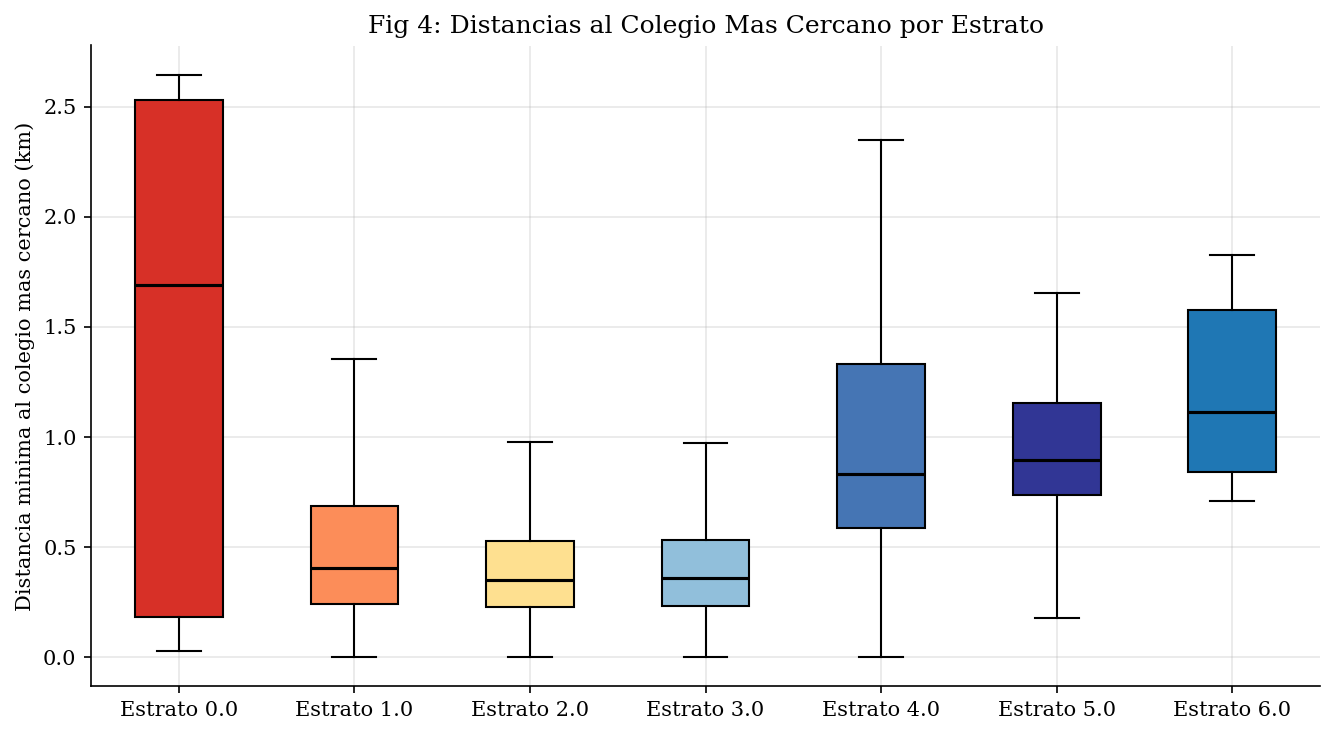

In [5]:
box_data4 = [
    fam_ing.loc[fam_ing["estrato_int"] == s, "dist_min"].dropna().values
    for s in strato_vals
]

fig, ax = plt.subplots(figsize=(9, 5))
bp4 = ax.boxplot(
    box_data4,
    patch_artist=True,
    showfliers=False,
    medianprops={"color": "black", "linewidth": 1.5},
)
for patch, color in zip(bp4["boxes"], COLORS6):
    patch.set_facecolor(color)
ax.set_xticklabels([f"Estrato {s}" for s in strato_vals])
ax.set_ylabel("Distancia minima al colegio mas cercano (km)")
ax.set_title("Fig 4: Distancias al Colegio Mas Cercano por Estrato")
plt.tight_layout()


plt.savefig(r"C:\paper-AI\reports\figures\eda\sim_04_distancia_minima_estrato.png", bbox_inches="tight", dpi=180)
plt.show()

## Fig 5: Hipersaturacion del Top-1

Los 15 colegios mas demandados como primera opcion vs su capacidad instalada.
Revela cuanto excede la demanda puntual a la oferta en los colegios mas populares.

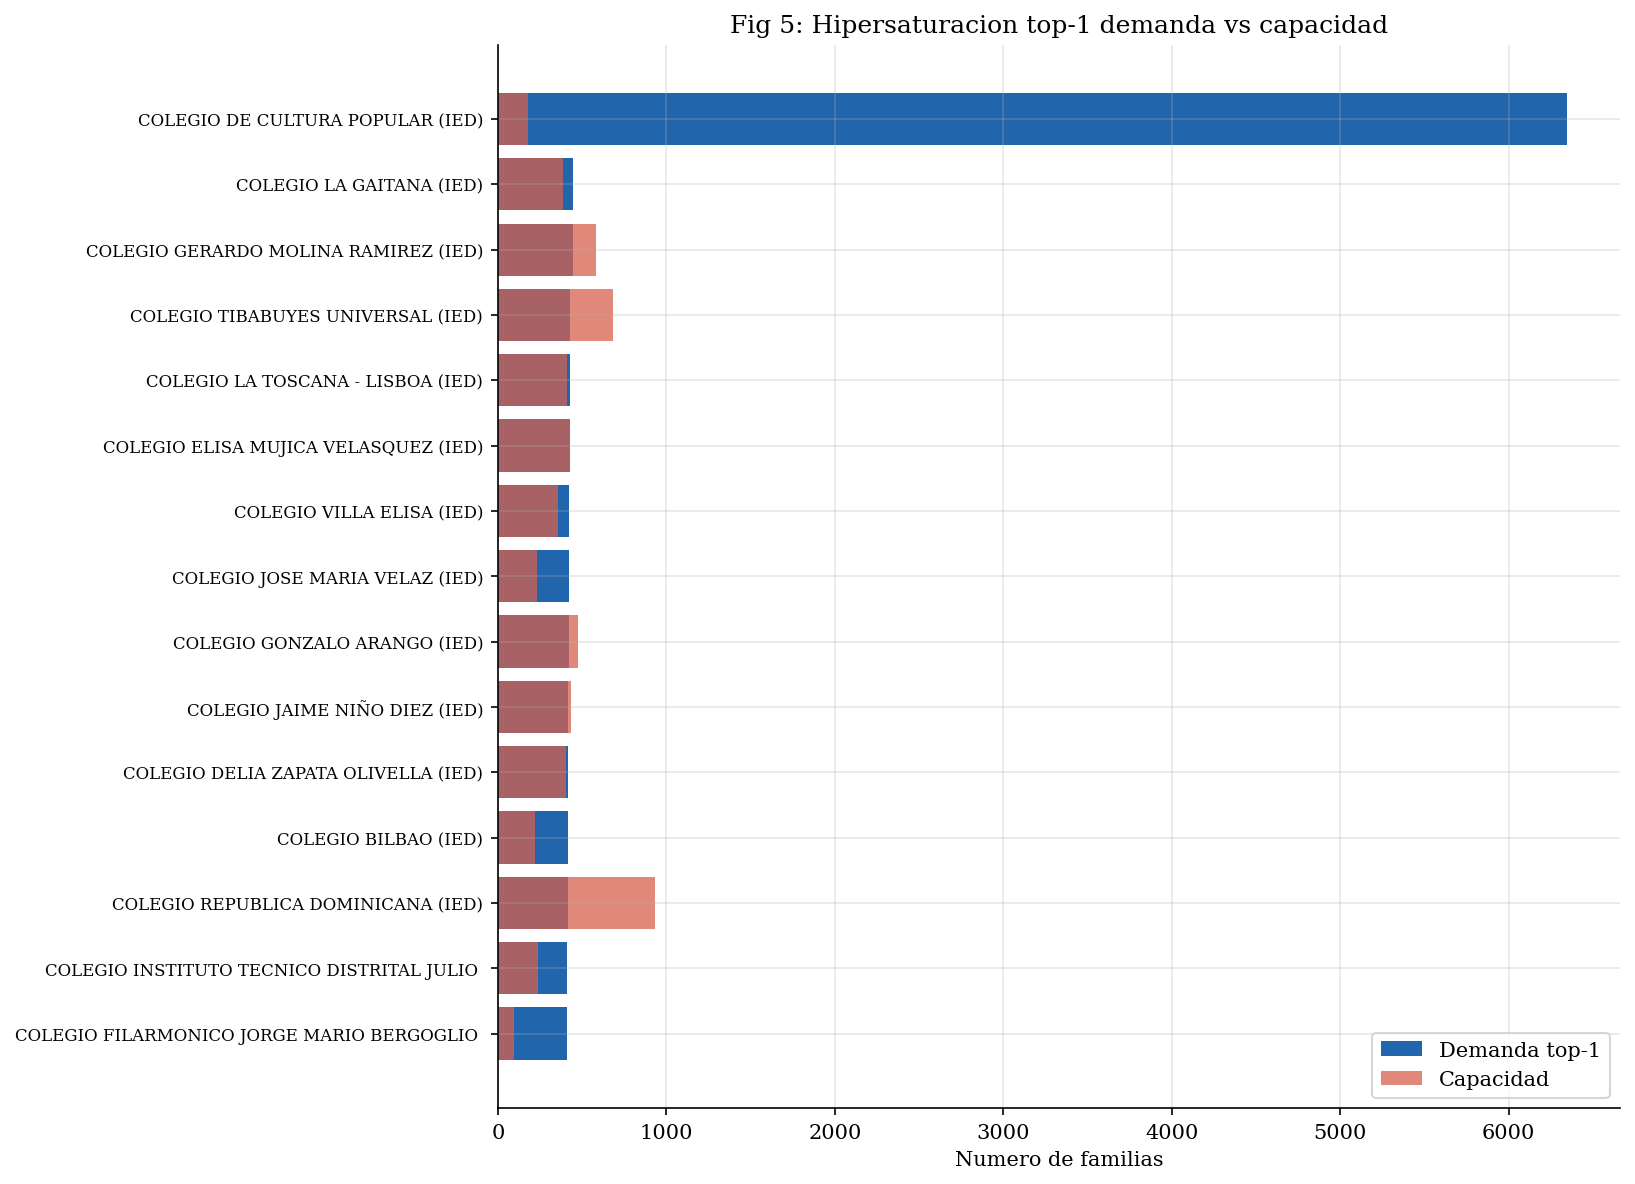

In [6]:
pref1_ser = fam_ing["pref_1"].dropna().astype(str)
top1_counts = pref1_ser.value_counts().head(15)

id_to_cap = colegios.set_index("id_establecimiento")["capacidad"].to_dict()
id_to_name = colegios.set_index("id_establecimiento")["nombre_establecimiento"].to_dict()

top1_df = pd.DataFrame({"id": top1_counts.index, "demanda": top1_counts.values})
top1_df["capacidad"] = top1_df["id"].map(id_to_cap).fillna(0)
top1_df["nombre"] = top1_df["id"].map(id_to_name).fillna(top1_df["id"])
top1_df["nombre"] = top1_df["nombre"].astype(str).str[:42]
top1_df = top1_df.sort_values("demanda", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 8))
y = np.arange(len(top1_df))
ax.barh(y, top1_df["demanda"],    color="#2166ac",             label="Demanda top-1")
ax.barh(y, top1_df["capacidad"], color="#d6604d", alpha=0.75, label="Capacidad")
ax.set_yticks(y)
ax.set_yticklabels(top1_df["nombre"], fontsize=8)
ax.set_xlabel("Numero de familias")
ax.set_title("Fig 5: Hipersaturacion top-1 demanda vs capacidad")
ax.legend()
plt.tight_layout()


plt.savefig(r"C:\paper-AI\reports\figures\eda\sim_05_hipersaturacion_top1.png", bbox_inches="tight", dpi=180)
plt.show()

## Fig 6: Tamano del Choice Set por Estrato

Numero de preferencias no nulas que cada familia declara, por estrato.
Un choice set mas grande puede reflejar mayor informacion o mayor movilidad de las familias.

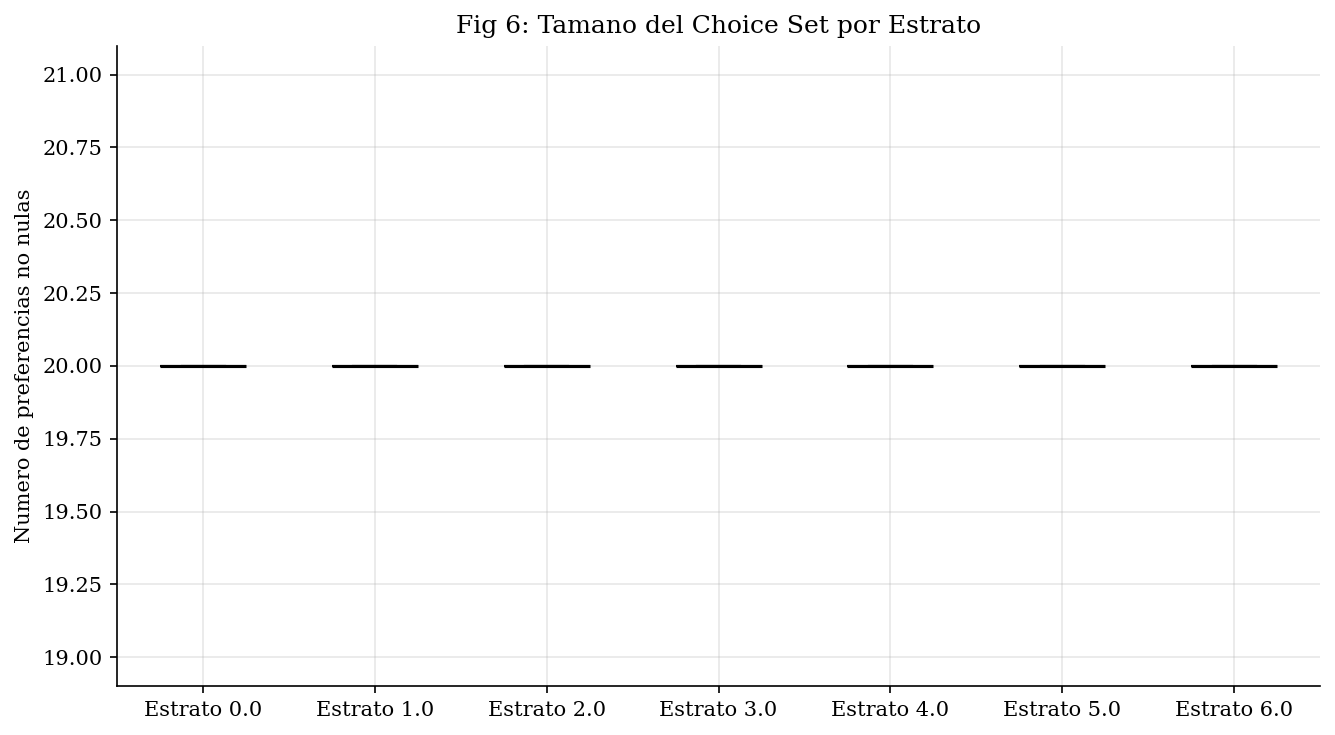

In [7]:
fam_ing["choice_set_size"] = fam_ing[pref_cols].notna().sum(axis=1)

box_data6 = [
    fam_ing.loc[fam_ing["estrato_int"] == s, "choice_set_size"].values
    for s in strato_vals
]

fig, ax = plt.subplots(figsize=(9, 5))
bp6 = ax.boxplot(
    box_data6,
    patch_artist=True,
    medianprops={"color": "black", "linewidth": 1.5},
)
for patch, color in zip(bp6["boxes"], COLORS6):
    patch.set_facecolor(color)
ax.set_xticklabels([f"Estrato {s}" for s in strato_vals])
ax.set_ylabel("Numero de preferencias no nulas")
ax.set_title("Fig 6: Tamano del Choice Set por Estrato")
plt.tight_layout()


plt.savefig(r"C:\paper-AI\reports\figures\eda\sim_06_choice_set_estrato.png", bbox_inches="tight", dpi=180)
plt.show()

## Tabla Resumen EDA

Estadisticas agregadas del dataset de primer ingreso: tamano, oferta, acceso geografico y choice set.

In [8]:
total_cupos = int(colegios["capacidad"].sum())
med_dist = float(np.nanmedian(fam_ing["dist_min"]))
med_cs = float(fam_ing["choice_set_size"].median())

print("=" * 62)
print("RESUMEN EDA SIMULACION")
print("=" * 62)
print(f"  Total familias expandidas      : {len(fam):>10,}")
print(f"  Familias primer ingreso        : {len(fam_ing):>10,}")
print(f"  Colegios en dataset            : {len(colegios):>10,}")
print(f"  Cupos totales                  : {total_cupos:>10,}")
print(f"  Ratio familias/cupos           : {len(fam_ing) / total_cupos:>10.2f}")
print(f"  Mediana distancia minima (km)  : {med_dist:>10.3f}")
print(f"  Mediana choice set size        : {med_cs:>10.1f}")
print()
print(f"  {'Estrato':<10} {'n familias':>12} {'dist_min med':>14} {'choice set med':>16}")
print(f"  {'-'*10} {'-'*12} {'-'*14} {'-'*16}")
for s in strato_vals:
    mask_s = fam_ing["estrato_int"] == s
    n_s = int(mask_s.sum())
    d_s = float(fam_ing.loc[mask_s, "dist_min"].median())
    c_s = float(fam_ing.loc[mask_s, "choice_set_size"].median())
    print(f"  {s:<10} {n_s:>12,} {d_s:>14.3f} {c_s:>16.1f}")

RESUMEN EDA SIMULACION
  Total familias expandidas      :    537,031
  Familias primer ingreso        :     99,890
  Colegios en dataset            :        366
  Cupos totales                  :    123,996
  Ratio familias/cupos           :       0.81
  Mediana distancia minima (km)  :      0.363
  Mediana choice set size        :       20.0

  Estrato      n familias   dist_min med   choice set med
  ---------- ------------ -------------- ----------------
  0.0                  87          1.692             20.0
  1.0              15,637          0.406             20.0
  2.0              57,109          0.350             20.0
  3.0              24,772          0.359             20.0
  4.0               1,357          0.832             20.0
  5.0                 566          0.896             20.0
  6.0                  67          1.114             20.0
